# 🌫️ PM2.5 Maroc — Ensemble, Tuning & Inference

**Suite du notebook Modeling_Baseline.**

| Étape | Contenu |
|-------|---------|
| 1 | Reload data + splits |
| 2 | Optuna tuning LightGBM (H+1) |
| 3 | Optuna tuning CatBoost (H+1) |
| 4 | Retrain meilleurs params → tous les horizons H1–H24 |
| 5 | Ensemble : Weighted Blend + Stacking |
| 6 | Analyse erreurs par ville et par heure |
| 7 | Analyse des pics extrêmes (p99) |
| 8 | Pipeline d'inférence temps réel (une ville, T → T+24) |
| 9 | Sauvegarde modèles finaux + résumé |

## 0. Configuration

In [27]:
# !pip install optuna lightgbm catboost xgboost scikit-learn joblib

In [ ]:
import warnings, gc, joblib, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────────
FE_DIR      = Path(r"E:\pipeline\test2\feature_engineering_outputs")
MODEL_DIR   = Path(r"E:\pipeline\test2\modeling_outputs")
ENSEMBLE_DIR= Path(r"E:\pipeline\test2\ensemble_outputs")
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Constantes ─────────────────────────────────────────────────────────────────
HORIZONS   = list(range(1, 25))
TARGET_H1  = "target24_h1"
TARGET_COLS= [f"target24_h{h}" for h in HORIZONS]
SEED       = 42
N_TRIALS   = 50

np.random.seed(SEED)
print("✅ Config OK")

✅ Config OK


## 1. Reload Data & Split

In [29]:
df = pd.read_csv(
    FE_DIR / "pm25_supervised_h1_h24.csv",
    engine="pyarrow",
    dtype_backend="pyarrow"
)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["city", "datetime"]).reset_index(drop=True)

# Features
with open(FE_DIR / "safe_feature_columns.txt") as f:
    SAFE_FEATURES = [l.strip() for l in f if l.strip()]

le = LabelEncoder()
df["city_enc"] = le.fit_transform(df["city"])

FEAT_NUM = [c for c in SAFE_FEATURES if c != "city"] + ["city_enc"]
FEAT_NUM = [c for c in FEAT_NUM if c in df.columns]
FEAT_CB  = [c for c in SAFE_FEATURES if c in df.columns]   # city string pour CatBoost
CAT_FEAT_CB = ["city"] if "city" in FEAT_CB else []

# Split temporel strict 80/10/10
dates     = df["datetime"].sort_values().unique()
n         = len(dates)
train_end = dates[int(n * 0.80)]
val_end   = dates[int(n * 0.90)]

df_train = df[df["datetime"] <  train_end].copy()
df_val   = df[(df["datetime"] >= train_end) & (df["datetime"] < val_end)].copy()
df_test  = df[df["datetime"] >= val_end].copy()

print(f"Train : {len(df_train):,} | Val : {len(df_val):,} | Test : {len(df_test):,}")
print(f"Features: {len(FEAT_NUM)}")

# Arrays numpy
X_tr  = df_train[FEAT_NUM].astype(float).values.astype(np.float32)
X_va  = df_val[FEAT_NUM].astype(float).values.astype(np.float32)
X_te  = df_test[FEAT_NUM].astype(float).values.astype(np.float32)

Train : 1,052,100 | Val : 131,500 | Test : 131,550
Features: 66


In [30]:
# ── Utilitaires ────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8
    return np.mean(num / den) * 100

def evaluate(name, y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = np.array(y_true)[mask], np.array(y_pred)[mask]
    return {
        "Model": name,
        "MAE":   round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE":  round(rmse(y_true, y_pred), 4),
        "SMAPE": round(smape(y_true, y_pred), 4),
        "R2":    round(r2_score(y_true, y_pred), 4),
        "N":     int(mask.sum()),
    }

def get_masks(target_col, split="train"):
    if split == "train": return df_train[target_col].notna().values
    if split == "val":   return df_val[target_col].notna().values
    return df_test[target_col].notna().values

RESULTS = []
print("✅ Utilitaires OK")

✅ Utilitaires OK


---
## 2. Optuna Tuning — LightGBM (sur H+1 uniquement)
> On optimise sur H+1, puis on utilisera les meilleurs params pour tous les horizons.

In [31]:
mask_tr_h1 = get_masks(TARGET_H1, "train")
mask_va_h1 = get_masks(TARGET_H1, "val")
mask_te_h1 = get_masks(TARGET_H1, "test")

y_tr_h1 = df_train.loc[mask_tr_h1, TARGET_H1].values.astype(np.float32)
y_va_h1 = df_val.loc[mask_va_h1,   TARGET_H1].values.astype(np.float32)
y_te_h1 = df_test.loc[mask_te_h1,  TARGET_H1].values.astype(np.float32)

lgb_tr = lgb.Dataset(X_tr[mask_tr_h1], label=y_tr_h1, free_raw_data=False)
lgb_va = lgb.Dataset(X_va[mask_va_h1], label=y_va_h1, reference=lgb_tr, free_raw_data=False)

def lgb_objective(trial):
    params = {
        "objective":         "regression",
        "metric":            "mae",
        "verbosity":         -1,
        "n_jobs":            -1,
        "random_state":      SEED,
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "max_depth":         trial.suggest_int("max_depth", 4, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
    }
    model = lgb.train(
        params, lgb_tr,
        num_boost_round=1000,
        valid_sets=[lgb_va],
        callbacks=[
            lgb.early_stopping(40, verbose=False),
            lgb.log_evaluation(-1),
        ]
    )
    preds = model.predict(X_va[mask_va_h1])
    return mean_absolute_error(y_va_h1, preds)

print(f"🔍 Optuna LightGBM — {N_TRIALS} trials...")
study_lgb = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="lgb_pm25_h1"
)
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1,
    "n_jobs": -1,
    "random_state": SEED,
})

print(f"\n✅ Best LGB MAE (val H+1): {study_lgb.best_value:.4f}")
print("Best params:")
for k, v in study_lgb.best_params.items():
    print(f"  {k}: {v}")

🔍 Optuna LightGBM — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best LGB MAE (val H+1): 0.5123
Best params:
  num_leaves: 181
  max_depth: 11
  learning_rate: 0.03294293892247954
  min_child_samples: 72
  subsample: 0.8066054552944254
  colsample_bytree: 0.7122309235479091
  reg_alpha: 0.45587990991896327
  reg_lambda: 0.0022377738453949678
  min_split_gain: 0.5524706853360891


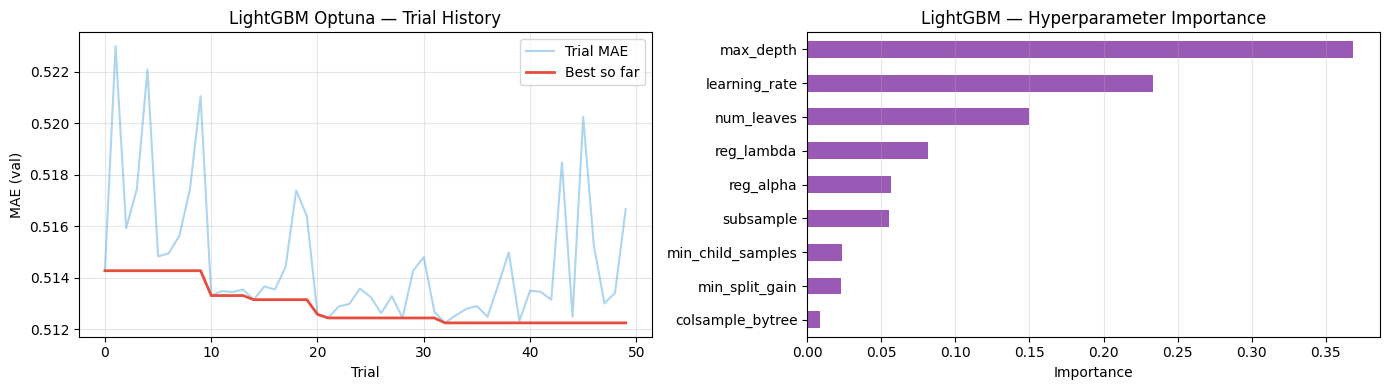

In [32]:
# ── Visualisation Optuna LGB ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Historique des trials
trial_vals = [t.value for t in study_lgb.trials if t.value is not None]
best_so_far = np.minimum.accumulate(trial_vals)
axes[0].plot(trial_vals, alpha=0.4, color="#3498DB", label="Trial MAE")
axes[0].plot(best_so_far, color="#E74C3C", lw=2, label="Best so far")
axes[0].set(title="LightGBM Optuna — Trial History", xlabel="Trial", ylabel="MAE (val)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Importance des hyperparamètres
try:
    importances = optuna.importance.get_param_importances(study_lgb)
    imp_df = pd.Series(importances).sort_values()
    imp_df.plot.barh(ax=axes[1], color="#9B59B6")
    axes[1].set(title="LightGBM — Hyperparameter Importance", xlabel="Importance")
    axes[1].grid(axis="x", alpha=0.3)
except:
    axes[1].text(0.5, 0.5, "Pas assez de trials", ha="center", va="center")

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "optuna_lgb.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 3. Optuna Tuning — CatBoost (sur H+1)

In [34]:
from catboost import Pool, CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna
import os

# ============================================================
# Préparation des Pools CatBoost
# ============================================================

cb_pool_tr = Pool(
    data=df_train.loc[mask_tr_h1, FEAT_CB].fillna(0),
    label=y_tr_h1,
    cat_features=CAT_FEAT_CB
)

cb_pool_va = Pool(
    data=df_val.loc[mask_va_h1, FEAT_CB].fillna(0),
    label=y_va_h1,
    cat_features=CAT_FEAT_CB
)

cb_pool_te = Pool(
    data=df_test.loc[mask_te_h1, FEAT_CB].fillna(0),
    cat_features=CAT_FEAT_CB
)

# ============================================================
# Fonction objectif Optuna
# ============================================================

def cb_objective(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            300,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            10.0
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            1.0
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            10.0
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        # Plus rapide que MAE mais on évalue toujours en MAE
        "loss_function": "RMSE",
        "eval_metric": "MAE",

        "random_seed": SEED,
        "verbose": 0,

        "task_type": "CPU",

        # Utilise tous les cœurs
        "thread_count": -1,

        # Early stopping
        "early_stopping_rounds": 30,

        # Conserve le meilleur modèle
        "use_best_model": True,
    }

    model = CatBoostRegressor(**params)

    model.fit(
        cb_pool_tr,
        eval_set=cb_pool_va
    )

    preds = model.predict(cb_pool_va)

    mae = mean_absolute_error(y_va_h1, preds)

    return mae


# ============================================================
# Etude Optuna
# ============================================================

print(f"🔍 Optuna CatBoost — {N_TRIALS} trials...")

study_cb = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),

    # Arrête automatiquement les mauvais essais
    pruner=MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=5
    ),

    study_name="cb_pm25_h1"
)

study_cb.optimize(
    cb_objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

# ============================================================
# Meilleurs paramètres
# ============================================================

best_cb_params = study_cb.best_params.copy()

best_cb_params.update({

    # Pour l'entraînement final
    "loss_function": "RMSE",
    "eval_metric": "MAE",

    "random_seed": SEED,

    "verbose": 0,

    "task_type": "CPU",

    "thread_count": -1,

    "early_stopping_rounds": 30,

    "use_best_model": True,
})

print("\n✅ Best CB MAE (val H+1):", study_cb.best_value)

print("\nBest parameters:")

for k, v in best_cb_params.items():
    print(f"{k}: {v}")

🔍 Optuna CatBoost — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best CB MAE (val H+1): 0.5118739831365747

Best parameters:
iterations: 888
learning_rate: 0.0612259455727524
depth: 10
l2_leaf_reg: 1.0130501061347816
bagging_temperature: 0.317820940294554
random_strength: 1.2384739311733268
border_count: 240
loss_function: RMSE
eval_metric: MAE
random_seed: 42
verbose: 0
task_type: CPU
thread_count: -1
early_stopping_rounds: 30
use_best_model: True


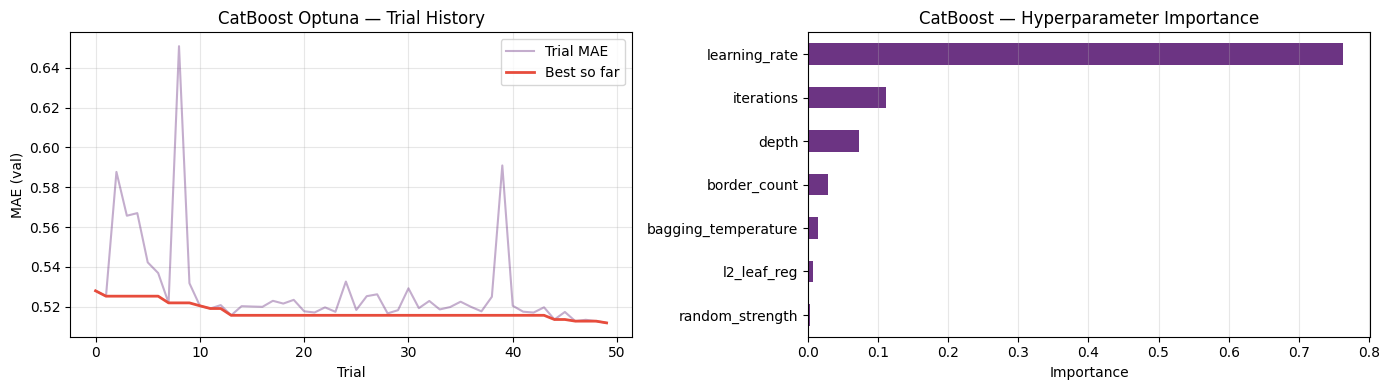

✅ Params sauvegardés


In [35]:
# ── Visualisation Optuna CB ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trial_vals_cb = [t.value for t in study_cb.trials if t.value is not None]
best_so_far_cb = np.minimum.accumulate(trial_vals_cb)
axes[0].plot(trial_vals_cb, alpha=0.4, color="#6C3483", label="Trial MAE")
axes[0].plot(best_so_far_cb, color="#E74C3C", lw=2, label="Best so far")
axes[0].set(title="CatBoost Optuna — Trial History", xlabel="Trial", ylabel="MAE (val)")
axes[0].legend(); axes[0].grid(alpha=0.3)

try:
    importances_cb = optuna.importance.get_param_importances(study_cb)
    imp_df_cb = pd.Series(importances_cb).sort_values()
    imp_df_cb.plot.barh(ax=axes[1], color="#6C3483")
    axes[1].set(title="CatBoost — Hyperparameter Importance", xlabel="Importance")
    axes[1].grid(axis="x", alpha=0.3)
except:
    axes[1].text(0.5, 0.5, "Pas assez de trials", ha="center", va="center")

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "optuna_cb.png", dpi=120, bbox_inches="tight")
plt.show()

# Sauvegarder les meilleurs params
with open(ENSEMBLE_DIR / "best_lgb_params.json", "w") as f:
    json.dump(best_lgb_params, f, indent=2)
with open(ENSEMBLE_DIR / "best_cb_params.json", "w") as f:
    json.dump(best_cb_params, f, indent=2)
print("✅ Params sauvegardés")

---
## 4. Retrain avec meilleurs params → H1–H24

In [36]:
# ── LightGBM tuné — tous horizons ─────────────────────────────────────────────
results_lgb_tuned = []
preds_lgb_tuned   = {}   # stocker preds test pour l'ensemble
models_lgb        = {}   # stocker modèles pour l'inférence

for h in HORIZONS:
    tc = f"target24_h{h}"
    mtr = get_masks(tc, "train")
    mva = get_masks(tc, "val")
    mte = get_masks(tc, "test")

    ds_tr = lgb.Dataset(X_tr[mtr], label=df_train.loc[mtr, tc].values.astype(np.float32), free_raw_data=False)
    ds_va = lgb.Dataset(X_va[mva], label=df_val.loc[mva, tc].values.astype(np.float32),   reference=ds_tr, free_raw_data=False)

    model = lgb.train(
        best_lgb_params, ds_tr,
        num_boost_round=1000,
        valid_sets=[ds_va],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    y_pred = model.predict(X_te[mte])
    y_true = df_test.loc[mte, tc].values.astype(np.float32)

    preds_lgb_tuned[h] = (y_true, y_pred, mte)
    models_lgb[h]      = model

    results_lgb_tuned.append({
        "Horizon": h,
        "MAE":     round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE":    round(rmse(y_true, y_pred), 3),
        "best_iter": model.best_iteration,
    })
    if h == 1:
        RESULTS.append(evaluate("LGB Tuned", y_true, y_pred))

    del ds_tr, ds_va; gc.collect()
    print(f"✓ LGB H+{h}  MAE={results_lgb_tuned[-1]['MAE']:.3f}")

df_lgb_tuned = pd.DataFrame(results_lgb_tuned)
print(f"\n→ MAE moyen H1–H24 : {df_lgb_tuned['MAE'].mean():.3f}")

✓ LGB H+1  MAE=0.644
✓ LGB H+2  MAE=1.086
✓ LGB H+3  MAE=1.423
✓ LGB H+4  MAE=1.695
✓ LGB H+5  MAE=1.918
✓ LGB H+6  MAE=2.106
✓ LGB H+7  MAE=2.241
✓ LGB H+8  MAE=2.365
✓ LGB H+9  MAE=2.465
✓ LGB H+10  MAE=2.550
✓ LGB H+11  MAE=2.625
✓ LGB H+12  MAE=2.689
✓ LGB H+13  MAE=2.744
✓ LGB H+14  MAE=2.808
✓ LGB H+15  MAE=2.870
✓ LGB H+16  MAE=2.909
✓ LGB H+17  MAE=2.952
✓ LGB H+18  MAE=3.000
✓ LGB H+19  MAE=3.042
✓ LGB H+20  MAE=3.102
✓ LGB H+21  MAE=3.141
✓ LGB H+22  MAE=3.187
✓ LGB H+23  MAE=3.234
✓ LGB H+24  MAE=3.266

→ MAE moyen H1–H24 : 2.503


In [37]:
# ── CatBoost tuné — tous horizons ─────────────────────────────────────────────
results_cb_tuned = []
preds_cb_tuned   = {}
models_cb        = {}

for h in HORIZONS:
    tc = f"target24_h{h}"
    mtr = get_masks(tc, "train")
    mva = get_masks(tc, "val")
    mte = get_masks(tc, "test")

    pool_tr = Pool(df_train.loc[mtr, FEAT_CB].fillna(0), label=df_train.loc[mtr, tc], cat_features=CAT_FEAT_CB)
    pool_va = Pool(df_val.loc[mva,   FEAT_CB].fillna(0), label=df_val.loc[mva, tc],   cat_features=CAT_FEAT_CB)
    pool_te = Pool(df_test.loc[mte,  FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)

    model = CatBoostRegressor(**best_cb_params)
    model.fit(pool_tr, eval_set=pool_va)

    y_pred = model.predict(pool_te)
    y_true = df_test.loc[mte, tc].values

    preds_cb_tuned[h] = (y_true, y_pred, mte)
    models_cb[h]      = model

    results_cb_tuned.append({
        "Horizon": h,
        "MAE":     round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE":    round(rmse(y_true, y_pred), 3),
        "best_iter": model.get_best_iteration(),
    })
    if h == 1:
        RESULTS.append(evaluate("CB Tuned", y_true, y_pred))

    del pool_tr, pool_va, pool_te; gc.collect()
    print(f"✓ CB H+{h}   MAE={results_cb_tuned[-1]['MAE']:.3f}")

df_cb_tuned = pd.DataFrame(results_cb_tuned)
print(f"\n→ MAE moyen H1–H24 : {df_cb_tuned['MAE'].mean():.3f}")

✓ CB H+1   MAE=0.644
✓ CB H+2   MAE=1.083
✓ CB H+3   MAE=1.421
✓ CB H+4   MAE=1.695
✓ CB H+5   MAE=1.920
✓ CB H+6   MAE=2.105
✓ CB H+7   MAE=2.253
✓ CB H+8   MAE=2.373
✓ CB H+9   MAE=2.483
✓ CB H+10   MAE=2.548
✓ CB H+11   MAE=2.642
✓ CB H+12   MAE=2.701
✓ CB H+13   MAE=2.754
✓ CB H+14   MAE=2.816
✓ CB H+15   MAE=2.860
✓ CB H+16   MAE=2.923
✓ CB H+17   MAE=2.976
✓ CB H+18   MAE=3.003
✓ CB H+19   MAE=3.012
✓ CB H+20   MAE=3.067
✓ CB H+21   MAE=3.065
✓ CB H+22   MAE=3.121
✓ CB H+23   MAE=3.164
✓ CB H+24   MAE=3.224

→ MAE moyen H1–H24 : 2.494


---
## 5. Ensemble
### 5A — Weighted Blend (recherche des poids optimaux)

In [38]:
from scipy.optimize import minimize

# ── Optimiser les poids sur le VAL SET H+1 ────────────────────────────────────
# Prédictions val pour chaque modèle
def get_val_preds_lgb(h):
    tc  = f"target24_h{h}"
    mva = get_masks(tc, "val")
    return models_lgb[h].predict(X_va[mva]), df_val.loc[mva, tc].values

def get_val_preds_cb(h):
    tc  = f"target24_h{h}"
    mva = get_masks(tc, "val")
    pool = Pool(df_val.loc[mva, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    return models_cb[h].predict(pool), df_val.loc[mva, tc].values

val_preds_lgb_h1, val_true_h1 = get_val_preds_lgb(1)
val_preds_cb_h1,  _           = get_val_preds_cb(1)

def blend_mae(weights):
    w = np.array(weights)
    w = w / w.sum()   # normaliser
    blend = w[0] * val_preds_lgb_h1 + w[1] * val_preds_cb_h1
    return mean_absolute_error(val_true_h1, blend)

# Optimisation Nelder-Mead
res = minimize(
    blend_mae,
    x0=[0.5, 0.5],
    method="Nelder-Mead",
    options={"maxiter": 1000}
)
opt_w = np.array(res.x)
opt_w = opt_w / opt_w.sum()

print(f"Poids optimaux : LGB={opt_w[0]:.3f}  CB={opt_w[1]:.3f}")
print(f"MAE blend val H+1 : {res.fun:.4f}")
print(f"MAE LGB seul val H+1 : {mean_absolute_error(val_true_h1, val_preds_lgb_h1):.4f}")
print(f"MAE CB  seul val H+1 : {mean_absolute_error(val_true_h1, val_preds_cb_h1):.4f}")

Poids optimaux : LGB=0.488  CB=0.512
MAE blend val H+1 : 0.5089
MAE LGB seul val H+1 : 0.5123
MAE CB  seul val H+1 : 0.5119


In [39]:
# ── Appliquer le blend sur TEST — tous horizons ────────────────────────────────
results_blend = []
preds_blend   = {}

for h in HORIZONS:
    y_true_lgb, y_pred_lgb, mte_lgb = preds_lgb_tuned[h]
    y_true_cb,  y_pred_cb,  mte_cb  = preds_cb_tuned[h]

    # Intersection des indices valides
    mask_both = mte_lgb & mte_cb

    # Recalculer sur mask commun
    tc = f"target24_h{h}"
    y_true = df_test.loc[mask_both, tc].values

    p_lgb = models_lgb[h].predict(X_te[mask_both])
    pool_te = Pool(df_test.loc[mask_both, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb  = models_cb[h].predict(pool_te)

    y_blend = opt_w[0] * p_lgb + opt_w[1] * p_cb
    preds_blend[h] = (y_true, y_blend)

    results_blend.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_blend), 3),
        "RMSE": round(rmse(y_true, y_blend), 3),
    })
    if h == 1:
        RESULTS.append(evaluate("Blend LGB+CB", y_true, y_blend))

df_blend = pd.DataFrame(results_blend)
display(df_blend)
print(f"\n→ MAE moyen H1–H24 : {df_blend['MAE'].mean():.3f}")

,Horizon,MAE,RMSE
0,1,0.6400,1.3590
1,2,1.0780,2.0370
2,3,1.4120,2.5780
3,4,1.6830,3.0060
4,5,1.9050,3.3530
5,6,2.0890,3.6350
6,7,2.2320,3.8560
7,8,2.3520,4.0320
8,9,2.4580,4.1930
9,10,2.5330,4.3040



→ MAE moyen H1–H24 : 2.481


### 5B — Stacking (méta-modèle Ridge)

In [40]:
# ── Stacking : méta-features = prédictions OOF ────────────────────────────────
# On utilise val comme méta-train, test comme méta-test

results_stack = []
preds_stack   = {}

for h in HORIZONS:
    tc  = f"target24_h{h}"
    mva = get_masks(tc, "val")
    mte = get_masks(tc, "test")
    mask_both_te = mte

    # ── Méta-features val (pour entraîner le méta-modèle) ──
    p_lgb_va = models_lgb[h].predict(X_va[mva])
    cb_va_pool = Pool(df_val.loc[mva, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb_va  = models_cb[h].predict(cb_va_pool)

    X_meta_va = np.column_stack([p_lgb_va, p_cb_va])
    y_meta_va = df_val.loc[mva, tc].values

    # ── Méta-features test ──
    p_lgb_te = models_lgb[h].predict(X_te[mte])
    cb_te_pool = Pool(df_test.loc[mte, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb_te  = models_cb[h].predict(cb_te_pool)

    X_meta_te = np.column_stack([p_lgb_te, p_cb_te])
    y_meta_te = df_test.loc[mte, tc].values

    # ── Méta-modèle Ridge ──
    meta = Ridge(alpha=1.0)
    meta.fit(X_meta_va, y_meta_va)
    y_stack = meta.predict(X_meta_te)

    preds_stack[h] = (y_meta_te, y_stack)

    results_stack.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_meta_te, y_stack), 3),
        "RMSE": round(rmse(y_meta_te, y_stack), 3),
        "LGB_w": round(meta.coef_[0], 3),
        "CB_w":  round(meta.coef_[1], 3),
    })
    if h == 1:
        RESULTS.append(evaluate("Stack Ridge", y_meta_te, y_stack))

df_stack = pd.DataFrame(results_stack)
display(df_stack)
print(f"\n→ MAE moyen H1–H24 : {df_stack['MAE'].mean():.3f}")

,Horizon,MAE,RMSE,LGB_w,CB_w
0,1,0.6400,1.3650,0.4530,0.5430
1,2,1.0770,2.0430,0.4830,0.5140
2,3,1.4100,2.5890,0.4490,0.5420
3,4,1.6800,3.0220,0.6410,0.3480
4,5,1.8980,3.3700,0.4560,0.5330
5,6,2.0820,3.6670,0.6470,0.3350
6,7,2.2230,3.8900,0.5080,0.4660
7,8,2.3440,4.0800,0.6330,0.3280
8,9,2.4480,4.2410,0.5450,0.4110
9,10,2.5270,4.3720,0.6230,0.3190



→ MAE moyen H1–H24 : 2.480


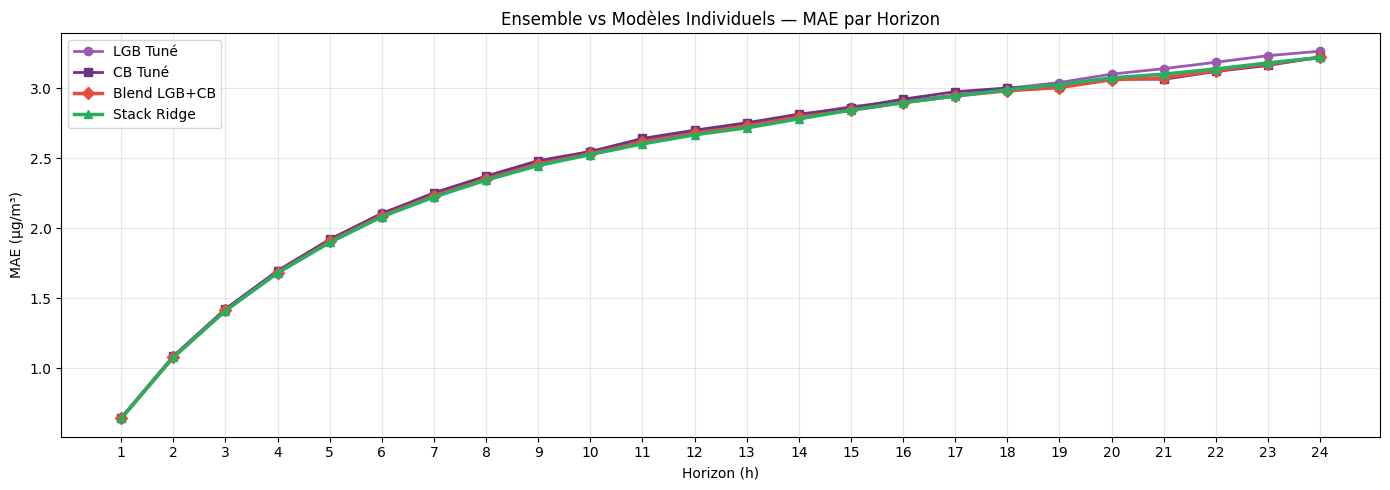

In [41]:
# ── Comparaison : LGB tuné vs CB tuné vs Blend vs Stack ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_lgb_tuned["Horizon"], df_lgb_tuned["MAE"],
        "o-", color="#9B59B6", lw=2, label="LGB Tuné")
ax.plot(df_cb_tuned["Horizon"],  df_cb_tuned["MAE"],
        "s-", color="#6C3483", lw=2, label="CB Tuné")
ax.plot(df_blend["Horizon"],     df_blend["MAE"],
        "D-", color="#E74C3C", lw=2.5, label="Blend LGB+CB")
ax.plot(df_stack["Horizon"],     df_stack["MAE"],
        "^-", color="#27AE60", lw=2.5, label="Stack Ridge")

ax.set(title="Ensemble vs Modèles Individuels — MAE par Horizon",
       xlabel="Horizon (h)", ylabel="MAE (µg/m³)")
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(HORIZONS)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
# ── Leaderboard final ─────────────────────────────────────────────────────────
df_lb = pd.DataFrame(RESULTS).sort_values("MAE")
df_lb.index = range(1, len(df_lb)+1)
display(df_lb.style
    .background_gradient(subset=["MAE","RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
    .format({"MAE":"{:.4f}","RMSE":"{:.4f}","SMAPE":"{:.2f}%","R2":"{:.4f}"})
)
df_lb.to_csv(ENSEMBLE_DIR / "leaderboard_ensemble.csv", index=False)

,Model,MAE,RMSE,SMAPE,R2,N
1,Blend LGB+CB,0.6396,1.3585,6.55%,0.9568,131550
2,Stack Ridge,0.6403,1.3646,6.55%,0.9564,131550
3,LGB Tuned,0.6437,1.3343,6.60%,0.9583,131550
4,CB Tuned,0.6442,1.3987,6.60%,0.9542,131550


---
## 6. Analyse des Erreurs par Ville & par Heure

In [43]:
# ── Stocker les prédictions du meilleur modèle (Blend) dans df_test ───────────
df_test = df_test.copy()

# Prédictions blend H+1 pour tout le test set
mte_h1 = get_masks(TARGET_H1, "test")
p_lgb_all = models_lgb[1].predict(X_te[mte_h1])
cb_te_all  = Pool(df_test.loc[mte_h1, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
p_cb_all   = models_cb[1].predict(cb_te_all)
blend_all  = opt_w[0] * p_lgb_all + opt_w[1] * p_cb_all

df_test.loc[mte_h1, "pred_blend_h1"] = blend_all
df_test.loc[mte_h1, "error_h1"]      = np.abs(blend_all - df_test.loc[mte_h1, TARGET_H1].values)
df_test.loc[mte_h1, "bias_h1"]       = blend_all - df_test.loc[mte_h1, TARGET_H1].values

print(f"Rows avec prédiction : {mte_h1.sum():,}")

Rows avec prédiction : 131,550


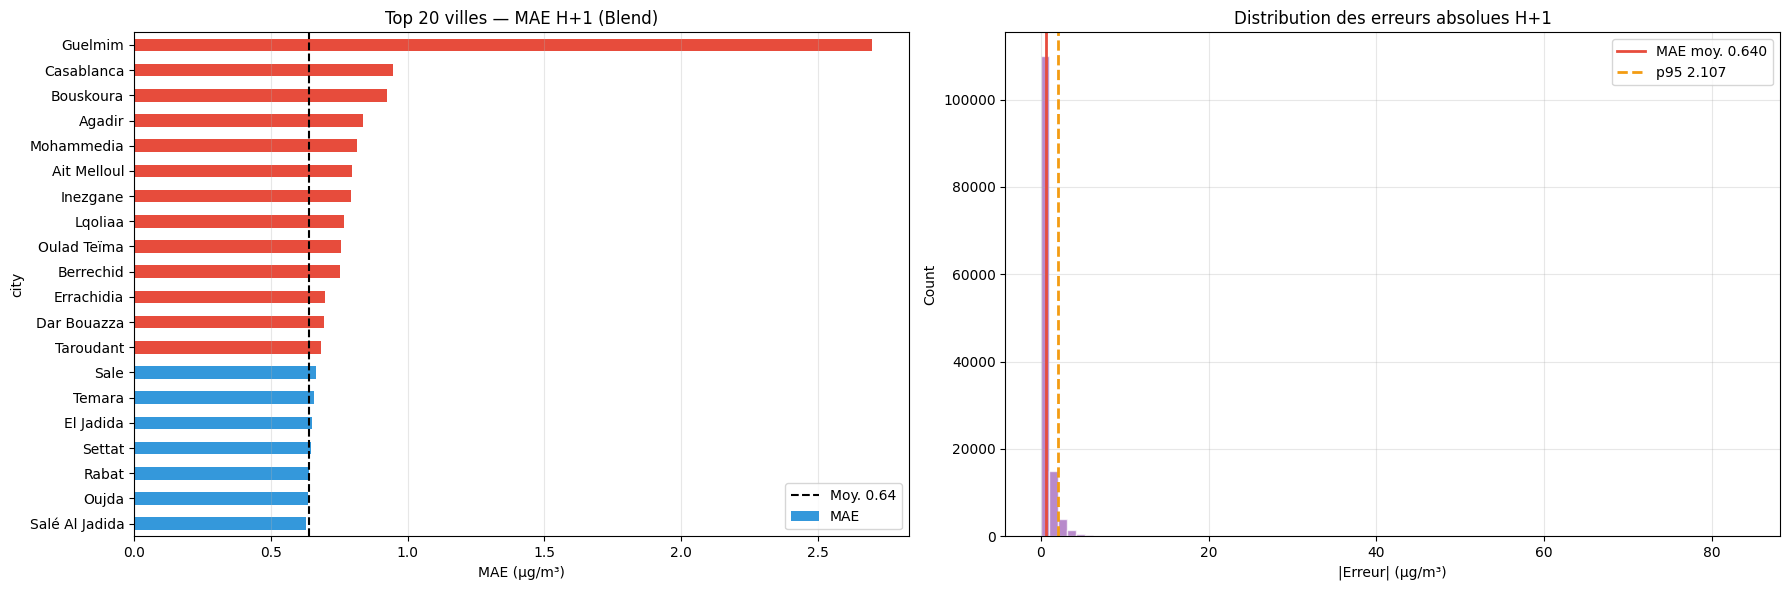

,MAE,Std,Max
city,,,
Guelmim,2.6966,5.9316,83.8847
Casablanca,0.9469,1.2466,12.3671
Bouskoura,0.9241,1.0876,11.8581
Agadir,0.8358,1.0209,8.9382
Mohammedia,0.8142,0.9852,9.6827
Ait Melloul,0.7950,1.0699,23.9828
Inezgane,0.7940,1.0692,23.9265
Lqoliaa,0.7670,1.0348,20.5361
Oulad Teïma,0.7573,1.0009,14.9949


In [44]:
# ── MAE par ville ─────────────────────────────────────────────────────────────
city_errors = (
    df_test.dropna(subset=["error_h1"])
    .groupby("city")["error_h1"]
    .agg(["mean", "std", "max"])
    .rename(columns={"mean":"MAE","std":"Std","max":"Max"})
    .sort_values("MAE", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 villes les plus difficiles
colors = ["#E74C3C" if v > city_errors["MAE"].quantile(0.75) else "#3498DB"
          for v in city_errors["MAE"].head(20)]
city_errors["MAE"].head(20).sort_values().plot.barh(
    ax=axes[0], color=colors[::-1]
)
axes[0].set(title="Top 20 villes — MAE H+1 (Blend)", xlabel="MAE (µg/m³)")
axes[0].axvline(city_errors["MAE"].mean(), color="black", lw=1.5,
                linestyle="--", label=f"Moy. {city_errors['MAE'].mean():.2f}")
axes[0].legend(); axes[0].grid(axis="x", alpha=0.3)

# Distribution des erreurs
axes[1].hist(df_test["error_h1"].dropna(), bins=80, color="#9B59B6", alpha=0.7, edgecolor="white")
axes[1].axvline(df_test["error_h1"].dropna().mean(), color="#E74C3C",
                lw=2, label=f"MAE moy. {df_test['error_h1'].dropna().mean():.3f}")
axes[1].axvline(df_test["error_h1"].dropna().quantile(0.95), color="#F39C12",
                lw=2, linestyle="--", label=f"p95 {df_test['error_h1'].dropna().quantile(0.95):.3f}")
axes[1].set(title="Distribution des erreurs absolues H+1", xlabel="|Erreur| (µg/m³)", ylabel="Count")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "error_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

display(city_errors.head(10))

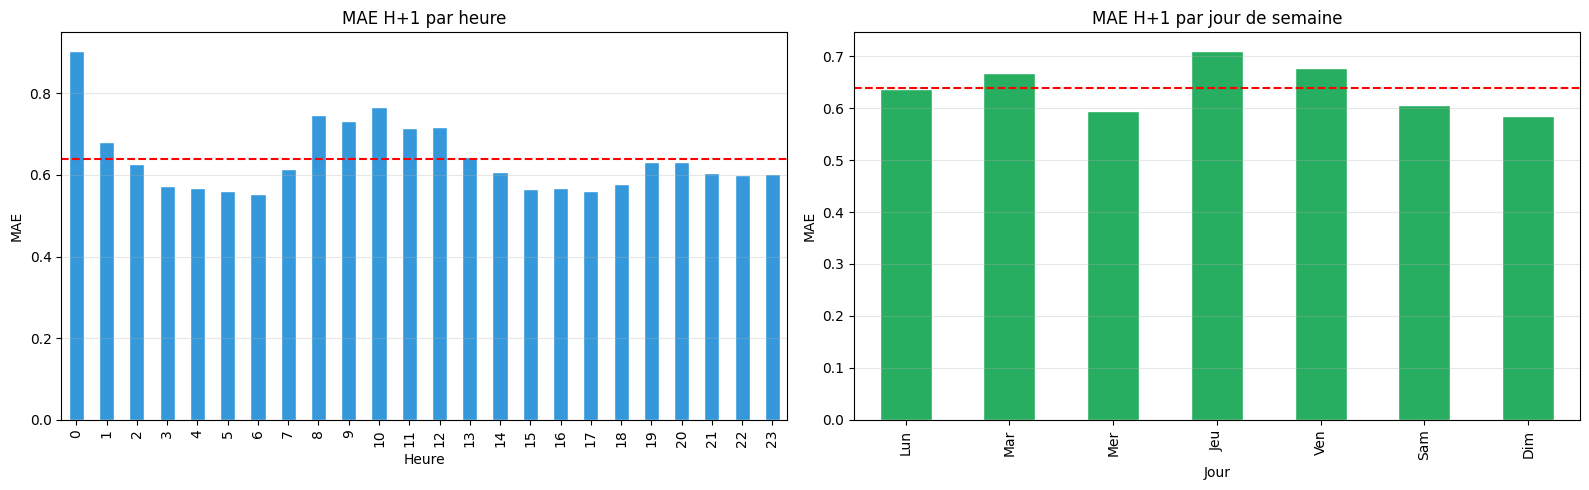

In [45]:
# ── MAE par heure de la journée & jour de semaine ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_err = df_test.dropna(subset=["error_h1"]).groupby("hour")["error_h1"].mean()
dow_err  = df_test.dropna(subset=["error_h1"]).groupby("dayofweek")["error_h1"].mean()

hour_err.plot(ax=axes[0], kind="bar", color="#3498DB", edgecolor="white")
axes[0].set(title="MAE H+1 par heure", xlabel="Heure", ylabel="MAE")
axes[0].axhline(hour_err.mean(), color="red", lw=1.5, linestyle="--")
axes[0].grid(axis="y", alpha=0.3)

dow_names = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
dow_err.index = dow_names
dow_err.plot(ax=axes[1], kind="bar", color="#27AE60", edgecolor="white")
axes[1].set(title="MAE H+1 par jour de semaine", xlabel="Jour", ylabel="MAE")
axes[1].axhline(dow_err.mean(), color="red", lw=1.5, linestyle="--")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "error_by_hour_dow.png", dpi=150, bbox_inches="tight")
plt.show()

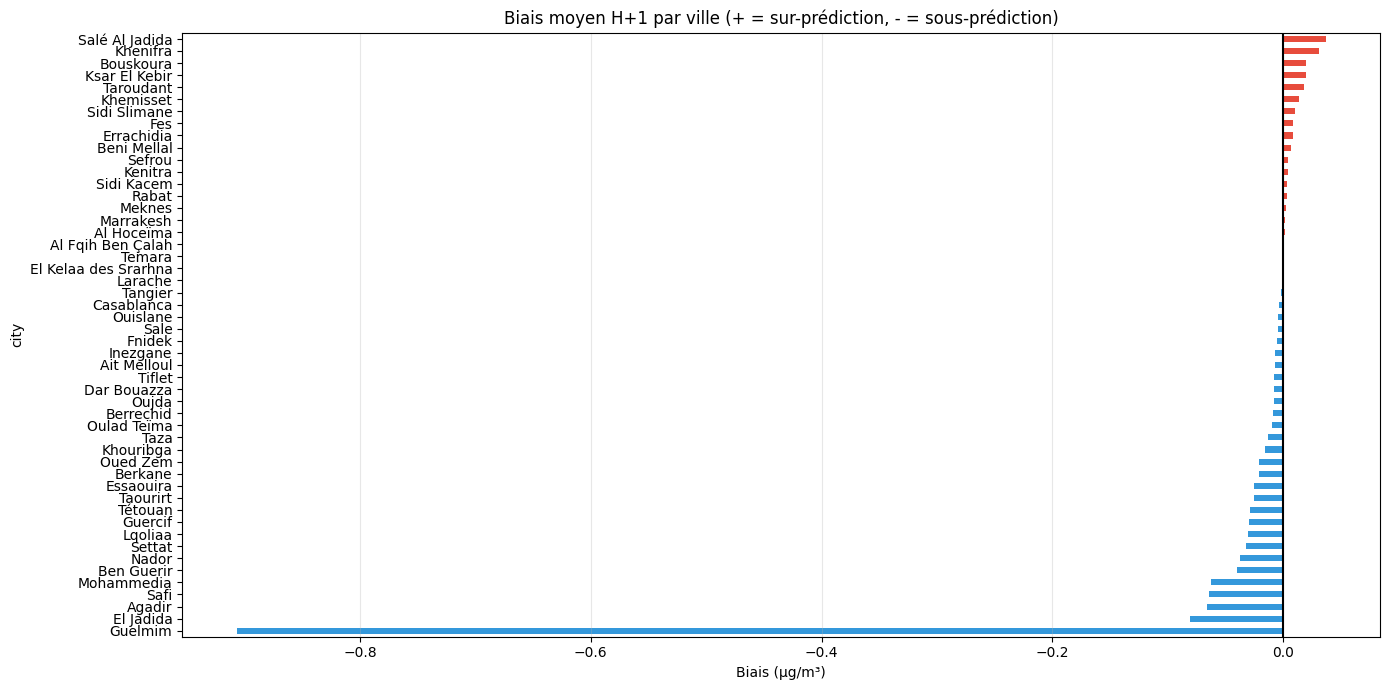

In [46]:
# ── Bias map : sur-prédiction vs sous-prédiction par ville ────────────────────
bias_city = (
    df_test.dropna(subset=["bias_h1"])
    .groupby("city")["bias_h1"].mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["#E74C3C" if v > 0 else "#3498DB" for v in bias_city]
bias_city.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", lw=1.5)
ax.set(title="Biais moyen H+1 par ville (+ = sur-prédiction, - = sous-prédiction)",
       xlabel="Biais (µg/m³)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "bias_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Analyse des Pics Extrêmes (p99)

Seuils PM2.5 — p75: 12.3  p90: 17.1  p99: 30.9 µg/m³


,MAE_mean,MAE_std,N
pm25_bin,,,
Normal (<p75),0.4493,0.5512,99069
Élevé (p75-p90),0.8730,0.9245,19371
Très élevé (p90-p99),1.3830,1.5098,11797
Extrême (>p99),4.8798,7.8403,1313


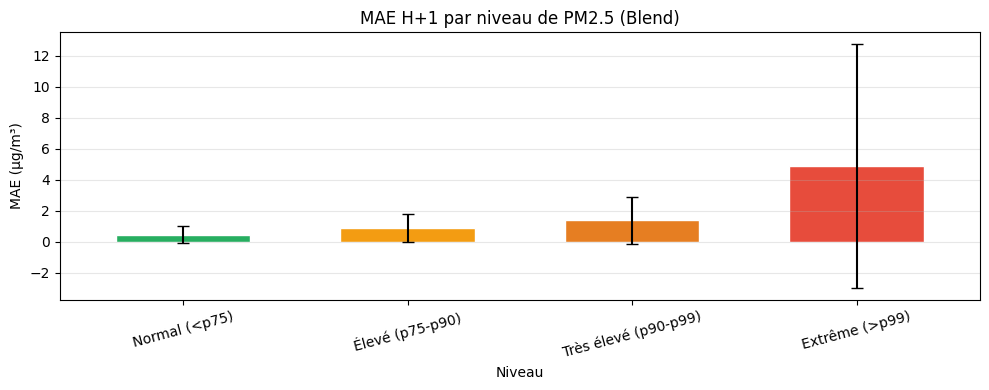

In [47]:
# ── Performance sur les valeurs extrêmes ──────────────────────────────────────
p99 = df_test[TARGET_H1].quantile(0.99)
p90 = df_test[TARGET_H1].quantile(0.90)
p75 = df_test[TARGET_H1].quantile(0.75)

print(f"Seuils PM2.5 — p75: {p75:.1f}  p90: {p90:.1f}  p99: {p99:.1f} µg/m³")

# Découper en bins
bins   = [0, p75, p90, p99, df_test[TARGET_H1].max() + 1]
labels = ["Normal (<p75)", "Élevé (p75-p90)", "Très élevé (p90-p99)", "Extrême (>p99)"]

df_test["pm25_bin"] = pd.cut(
    df_test[TARGET_H1], bins=bins, labels=labels, include_lowest=True
)

extreme_perf = (
    df_test.dropna(subset=["error_h1", "pm25_bin"])
    .groupby("pm25_bin", observed=True)["error_h1"]
    .agg(["mean","std","count"])
    .rename(columns={"mean":"MAE_mean","std":"MAE_std","count":"N"})
)
display(extreme_perf)

fig, ax = plt.subplots(figsize=(10, 4))
extreme_perf["MAE_mean"].plot.bar(
    ax=ax,
    color=["#27AE60","#F39C12","#E67E22","#E74C3C"],
    edgecolor="white", width=0.6
)
ax.errorbar(
    x=range(len(extreme_perf)),
    y=extreme_perf["MAE_mean"],
    yerr=extreme_perf["MAE_std"],
    fmt="none", color="black", capsize=4
)
ax.set(title="MAE H+1 par niveau de PM2.5 (Blend)",
       xlabel="Niveau", ylabel="MAE (µg/m³)")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "error_by_pm25_level.png", dpi=150, bbox_inches="tight")
plt.show()

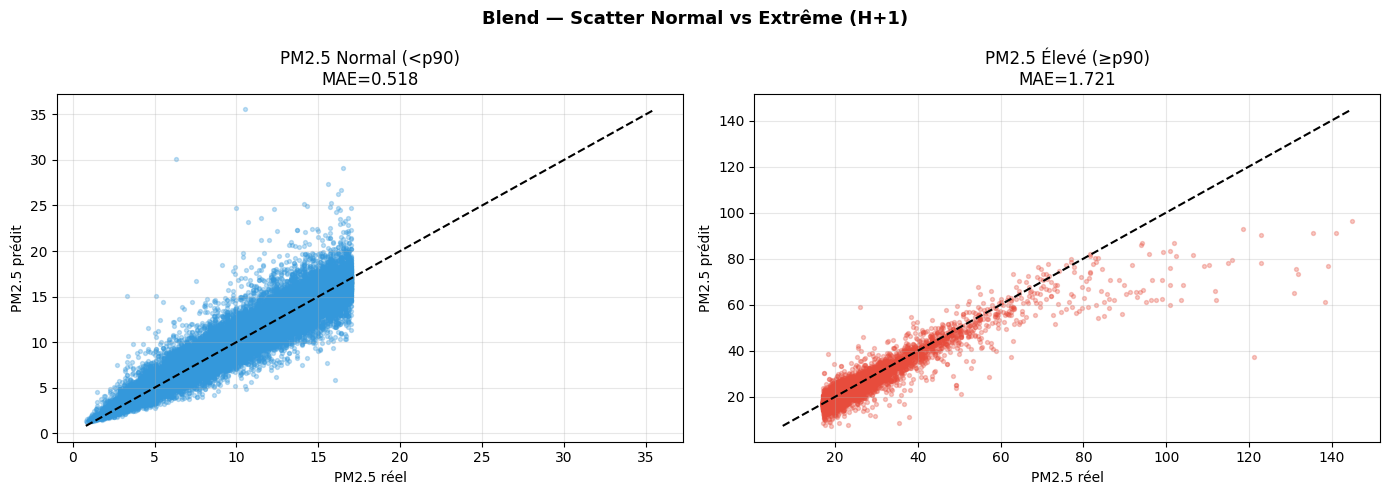

In [48]:
# ── Scatter extremes ──────────────────────────────────────────────────────────
df_extreme = df_test[df_test[TARGET_H1] >= p90].dropna(subset=["pred_blend_h1"])
df_normal  = df_test[df_test[TARGET_H1] <  p90].dropna(subset=["pred_blend_h1"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_sub, title, color in zip(
    axes,
    [df_normal, df_extreme],
    ["PM2.5 Normal (<p90)", "PM2.5 Élevé (≥p90)"],
    ["#3498DB", "#E74C3C"]
):
    ax.scatter(df_sub[TARGET_H1].values,
               df_sub["pred_blend_h1"].values,
               alpha=0.3, s=8, color=color)
    lim_min = min(df_sub[TARGET_H1].min(), df_sub["pred_blend_h1"].min())
    lim_max = max(df_sub[TARGET_H1].max(), df_sub["pred_blend_h1"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1.5)
    mae_sub = mean_absolute_error(df_sub[TARGET_H1], df_sub["pred_blend_h1"])
    ax.set(title=f"{title}\nMAE={mae_sub:.3f}",
           xlabel="PM2.5 réel", ylabel="PM2.5 prédit")
    ax.grid(alpha=0.3)

plt.suptitle("Blend — Scatter Normal vs Extrême (H+1)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "scatter_extreme_vs_normal.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Pipeline d'Inférence Temps Réel
> **Entrée** : nom de ville + heure courante T  
> **Sortie** : prédictions PM2.5 pour T+1 → T+24

In [49]:
class PM25Predictor:
    """
    Pipeline d'inférence temps réel PM2.5.
    Utilise les modèles LGB + CB tunés + blend.
    """

    def __init__(self, models_lgb, models_cb, blend_weights,
                 feat_num, feat_cb, cat_feat_cb, label_encoder):
        self.models_lgb    = models_lgb      # dict {h: lgb_model}
        self.models_cb     = models_cb       # dict {h: cb_model}
        self.blend_w       = blend_weights   # [w_lgb, w_cb]
        self.feat_num      = feat_num
        self.feat_cb       = feat_cb
        self.cat_feat_cb   = cat_feat_cb
        self.le            = label_encoder

    def _build_row(self, city: str, dt: pd.Timestamp,
                   historical_df: pd.DataFrame) -> pd.DataFrame:
        """
        Construit une ligne de features pour (city, dt) à partir de
        l'historique passé (doit contenir au moins 336h de données).
        """
        city_hist = historical_df[
            (historical_df["city"] == city) &
            (historical_df["datetime"] < dt)
        ].sort_values("datetime").tail(336)

        if len(city_hist) < 24:
            raise ValueError(f"Pas assez d'historique pour {city} à {dt}")

        row = {"city": city, "datetime": dt}

        # Features temporelles
        row["hour"]      = dt.hour
        row["dayofweek"] = dt.dayofweek
        row["month"]     = dt.month
        row["day"]       = dt.day
        row["weekofyear"]= dt.isocalendar()[1]
        row["hour_sin"]  = np.sin(2 * np.pi * dt.hour / 24)
        row["hour_cos"]  = np.cos(2 * np.pi * dt.hour / 24)
        row["dow_sin"]   = np.sin(2 * np.pi * dt.dayofweek / 7)
        row["dow_cos"]   = np.cos(2 * np.pi * dt.dayofweek / 7)
        row["month_sin"] = np.sin(2 * np.pi * dt.month / 12)
        row["month_cos"] = np.cos(2 * np.pi * dt.month / 12)

        # Coordonnées (depuis l'historique)
        row["lat"] = city_hist["lat"].iloc[-1]
        row["lon"] = city_hist["lon"].iloc[-1]

        # Lags PM2.5
        pm25_series = city_hist.set_index("datetime")["pm2_5"]
        for lag in [1,2,3,6,12,24,48,72,168,336]:
            lag_dt = dt - pd.Timedelta(hours=lag)
            row[f"pm25_lag_{lag}h"] = pm25_series.get(lag_dt, np.nan)

        # Rolling features (sur les 168 dernières heures)
        pm25_vals = pm25_series.values
        for w in [3,6,12,24,48,72,168]:
            slice_w = pm25_vals[-w:] if len(pm25_vals) >= w else pm25_vals
            row[f"roll_mean_{w}h"] = np.nanmean(slice_w)
            row[f"roll_std_{w}h"]  = np.nanstd(slice_w)
            row[f"roll_min_{w}h"]  = np.nanmin(slice_w)
            row[f"roll_max_{w}h"]  = np.nanmax(slice_w)

        # Changes & EWM
        pm25_1h = row.get("pm25_lag_1h", np.nan)
        pm25_2h = row.get("pm25_lag_2h", np.nan)
        row["pm25_change_1h"] = np.nan if np.isnan(pm25_1h) else pm25_vals[-1] - pm25_1h if len(pm25_vals)>0 else np.nan
        row["pm25_change_3h"] = pm25_vals[-1] - row.get("pm25_lag_3h", np.nan) if len(pm25_vals)>0 else np.nan
        row["pm25_change_6h"] = pm25_vals[-1] - row.get("pm25_lag_6h", np.nan) if len(pm25_vals)>0 else np.nan
        row["pm25_change_24h"]= pm25_vals[-1] - row.get("pm25_lag_24h", np.nan) if len(pm25_vals)>0 else np.nan

        ewm_series = pd.Series(pm25_vals)
        row["pm25_ewm_6h"]  = ewm_series.ewm(span=6).mean().iloc[-1]  if len(ewm_series)>0 else np.nan
        row["pm25_ewm_24h"] = ewm_series.ewm(span=24).mean().iloc[-1] if len(ewm_series)>0 else np.nan

        # Météo (dernière valeur)
        last = city_hist.iloc[-1]
        row["temp_change_1h"]    = city_hist["temperature"].diff().iloc[-1] if "temperature" in city_hist else np.nan
        row["humidity_change_1h"]= city_hist["humidity"].diff().iloc[-1]    if "humidity"    in city_hist else np.nan
        row["temp_humidity"]     = last.get("temperature", np.nan) * last.get("humidity", np.nan)
        row["temp_wind"]         = last.get("temperature", np.nan) * last.get("wind_speed", np.nan)
        row["humidity_wind"]     = last.get("humidity",    np.nan) * last.get("wind_speed", np.nan)

        # Moyennes historiques (approximation)
        row["pm25_city_hour_mean"] = pm25_series[pm25_series.index.hour == dt.hour].mean()
        row["pm25_city_dow_mean"]  = pm25_series[pm25_series.index.dayofweek == dt.dayofweek].mean()
        row["pm25_city_month_mean"]= pm25_series[pm25_series.index.month == dt.month].mean()

        # City encoding
        row["city_enc"] = self.le.transform([city])[0] if city in self.le.classes_ else -1

        return pd.DataFrame([row])

    def predict(self, city: str, dt: pd.Timestamp,
                historical_df: pd.DataFrame) -> pd.DataFrame:
        """
        Retourne un DataFrame avec les prédictions H+1 → H+24.
        """
        row_df = self._build_row(city, dt, historical_df)

        preds = {}
        for h in range(1, 25):
            # LGB
            x_lgb = row_df[self.feat_num].fillna(0).values.astype(np.float32)
            p_lgb = self.models_lgb[h].predict(x_lgb)[0]

            # CB
            pool = Pool(row_df[self.feat_cb].fillna(0), cat_features=self.cat_feat_cb)
            p_cb = self.models_cb[h].predict(pool)[0]

            # Blend
            p_blend = self.blend_w[0] * p_lgb + self.blend_w[1] * p_cb
            p_blend = max(0.0, p_blend)   # PM2.5 ne peut pas être négatif

            preds[f"H+{h}"] = round(p_blend, 2)

        forecast_times = [dt + pd.Timedelta(hours=h) for h in range(1, 25)]
        return pd.DataFrame({
            "datetime":     forecast_times,
            "horizon":      [f"H+{h}" for h in range(1, 25)],
            "pm25_pred":    list(preds.values()),
            "city":         city,
        })


# ── Instancier le predictor ───────────────────────────────────────────────────
predictor = PM25Predictor(
    models_lgb    = models_lgb,
    models_cb     = models_cb,
    blend_weights = opt_w,
    feat_num      = FEAT_NUM,
    feat_cb       = FEAT_CB,
    cat_feat_cb   = CAT_FEAT_CB,
    label_encoder = le,
)
print("✅ PM25Predictor instancié")

✅ PM25Predictor instancié


In [50]:
# ── Test de l'inférence sur Casablanca ────────────────────────────────────────
CITY_INF = "Casablanca"
# Utiliser la dernière heure du test set comme T
T_now = df_test[df_test["city"] == CITY_INF]["datetime"].max() - pd.Timedelta(hours=24)

# historical_df doit contenir les données brutes avec pm2_5
historical_df = df.copy()   # ou charger le CSV original

print(f"🔮 Inférence pour {CITY_INF} à T = {T_now}")
forecast = predictor.predict(CITY_INF, T_now, historical_df)
display(forecast)

# Vérité terrain (si disponible)
ground_truth = df_test[
    (df_test["city"] == CITY_INF) &
    (df_test["datetime"] > T_now) &
    (df_test["datetime"] <= T_now + pd.Timedelta(hours=24))
][["datetime","pm2_5"]].sort_values("datetime")

if len(ground_truth) > 0:
    forecast_merged = forecast.merge(
        ground_truth.rename(columns={"pm2_5":"pm25_real"}),
        on="datetime", how="left"
    )
    mae_inf = mean_absolute_error(
        forecast_merged["pm25_real"].dropna(),
        forecast_merged.loc[forecast_merged["pm25_real"].notna(), "pm25_pred"]
    )
    print(f"\nMAE inférence vs réel : {mae_inf:.3f} µg/m³")

🔮 Inférence pour Casablanca à T = 2026-06-07 22:00:00


,datetime,horizon,pm25_pred,city
0,2026-06-07 23:00:00,H+1,15.0200,Casablanca
1,2026-06-08 00:00:00,H+2,15.2400,Casablanca
2,2026-06-08 01:00:00,H+3,15.8400,Casablanca
3,2026-06-08 02:00:00,H+4,16.4300,Casablanca
4,2026-06-08 03:00:00,H+5,17.3200,Casablanca
5,2026-06-08 04:00:00,H+6,17.6400,Casablanca
6,2026-06-08 05:00:00,H+7,17.8100,Casablanca
7,2026-06-08 06:00:00,H+8,17.8600,Casablanca
8,2026-06-08 07:00:00,H+9,17.8500,Casablanca
9,2026-06-08 08:00:00,H+10,17.3000,Casablanca



MAE inférence vs réel : 3.985 µg/m³


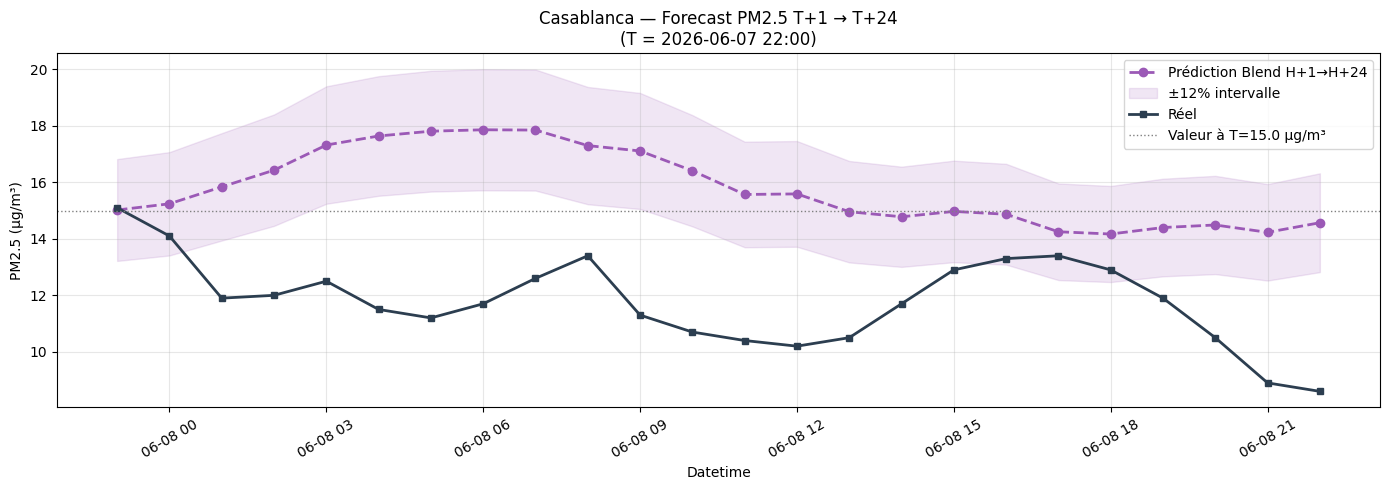

In [51]:
# ── Visualisation inférence ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(forecast["datetime"], forecast["pm25_pred"],
        "o--", color="#9B59B6", lw=2, markersize=6, label="Prédiction Blend H+1→H+24")

ax.fill_between(
    forecast["datetime"],
    forecast["pm25_pred"] * 0.88,
    forecast["pm25_pred"] * 1.12,
    alpha=0.15, color="#9B59B6", label="±12% intervalle"
)

if len(ground_truth) > 0:
    ax.plot(ground_truth["datetime"], ground_truth["pm2_5"],
            "s-", color="#2C3E50", lw=2, markersize=5, label="Réel")

# Ligne de référence dernière valeur connue
last_known = historical_df[
    (historical_df["city"] == CITY_INF) &
    (historical_df["datetime"] == T_now)
]["pm2_5"].values
if len(last_known) > 0:
    ax.axhline(last_known[0], color="gray", lw=1, linestyle=":",
               label=f"Valeur à T={last_known[0]:.1f} µg/m³")

ax.set(
    title=f"{CITY_INF} — Forecast PM2.5 T+1 → T+24\n(T = {T_now.strftime('%Y-%m-%d %H:00')})",
    xlabel="Datetime", ylabel="PM2.5 (µg/m³)"
)
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / f"inference_{CITY_INF.lower()}_{T_now.strftime('%Y%m%d_%H')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Sauvegarde Modèles Finaux

In [52]:
# ── Sauvegarder tous les modèles LGB ──────────────────────────────────────────
lgb_dir = ENSEMBLE_DIR / "models_lgb"
lgb_dir.mkdir(exist_ok=True)
for h, model in models_lgb.items():
    model.save_model(str(lgb_dir / f"lgb_h{h}.txt"))
print(f"✅ {len(models_lgb)} modèles LGB sauvegardés → {lgb_dir}")

# ── Sauvegarder tous les modèles CatBoost ─────────────────────────────────────
cb_dir = ENSEMBLE_DIR / "models_cb"
cb_dir.mkdir(exist_ok=True)
for h, model in models_cb.items():
    model.save_model(str(cb_dir / f"cb_h{h}.cbm"))
print(f"✅ {len(models_cb)} modèles CB sauvegardés → {cb_dir}")

# ── Sauvegarder le LabelEncoder et les poids ──────────────────────────────────
joblib.dump(le, ENSEMBLE_DIR / "label_encoder.pkl")
np.save(ENSEMBLE_DIR / "blend_weights.npy", opt_w)

# ── Sauvegarder les listes de features ────────────────────────────────────────
with open(ENSEMBLE_DIR / "feat_num.json", "w") as f:
    json.dump(FEAT_NUM, f)
with open(ENSEMBLE_DIR / "feat_cb.json", "w") as f:
    json.dump(FEAT_CB, f)

print("\n📁 Contenu ensemble_outputs:")
for p in sorted(ENSEMBLE_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(ENSEMBLE_DIR)}")

✅ 24 modèles LGB sauvegardés → E:\pipeline\test2\ensemble_outputs\models_lgb
✅ 24 modèles CB sauvegardés → E:\pipeline\test2\ensemble_outputs\models_cb

📁 Contenu ensemble_outputs:
  best_cb_params.json
  best_lgb_params.json
  bias_by_city.png
  blend_weights.npy
  ensemble_comparison.png
  error_by_city.png
  error_by_hour_dow.png
  error_by_pm25_level.png
  feat_cb.json
  feat_num.json
  inference_casablanca_20260607_22.png
  label_encoder.pkl
  leaderboard_ensemble.csv
  models_cb\cb_h1.cbm
  models_cb\cb_h10.cbm
  models_cb\cb_h11.cbm
  models_cb\cb_h12.cbm
  models_cb\cb_h13.cbm
  models_cb\cb_h14.cbm
  models_cb\cb_h15.cbm
  models_cb\cb_h16.cbm
  models_cb\cb_h17.cbm
  models_cb\cb_h18.cbm
  models_cb\cb_h19.cbm
  models_cb\cb_h2.cbm
  models_cb\cb_h20.cbm
  models_cb\cb_h21.cbm
  models_cb\cb_h22.cbm
  models_cb\cb_h23.cbm
  models_cb\cb_h24.cbm
  models_cb\cb_h3.cbm
  models_cb\cb_h4.cbm
  models_cb\cb_h5.cbm
  models_cb\cb_h6.cbm
  models_cb\cb_h7.cbm
  models_cb\cb_h8.cbm
 

In [53]:
# ── Résumé final ──────────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  🏆  RÉSUMÉ FINAL — ENSEMBLE")
print("═" * 65)

summary = pd.DataFrame({
    "Modèle":        ["LGB Tuné", "CB Tuné", "Blend LGB+CB", "Stack Ridge"],
    "MAE_mean":      [
        df_lgb_tuned["MAE"].mean().round(3),
        df_cb_tuned["MAE"].mean().round(3),
        df_blend["MAE"].mean().round(3),
        df_stack["MAE"].mean().round(3),
    ],
    "MAE_H1":  [
        df_lgb_tuned.iloc[0]["MAE"],
        df_cb_tuned.iloc[0]["MAE"],
        df_blend.iloc[0]["MAE"],
        df_stack.iloc[0]["MAE"],
    ],
    "MAE_H12": [
        df_lgb_tuned.iloc[11]["MAE"],
        df_cb_tuned.iloc[11]["MAE"],
        df_blend.iloc[11]["MAE"],
        df_stack.iloc[11]["MAE"],
    ],
    "MAE_H24": [
        df_lgb_tuned.iloc[23]["MAE"],
        df_cb_tuned.iloc[23]["MAE"],
        df_blend.iloc[23]["MAE"],
        df_stack.iloc[23]["MAE"],
    ],
}).sort_values("MAE_mean")

display(summary.style.background_gradient(
    subset=["MAE_mean","MAE_H1","MAE_H12","MAE_H24"], cmap="RdYlGn_r"
))

summary.to_csv(ENSEMBLE_DIR / "ensemble_summary.csv", index=False)
print(f"\n✅ Tout sauvegardé dans {ENSEMBLE_DIR}")
print(f"🔮 Predictor prêt → predictor.predict(city, datetime, historical_df)")


═════════════════════════════════════════════════════════════════
  🏆  RÉSUMÉ FINAL — ENSEMBLE
═════════════════════════════════════════════════════════════════


,Modèle,MAE_mean,MAE_H1,MAE_H12,MAE_H24
3,Stack Ridge,2.480000,0.640000,2.668000,3.221000
2,Blend LGB+CB,2.481000,0.640000,2.678000,3.221000
1,CB Tuné,2.494000,0.644000,2.701000,3.224000
0,LGB Tuné,2.503000,0.644000,2.689000,3.266000



✅ Tout sauvegardé dans E:\pipeline\test2\ensemble_outputs
🔮 Predictor prêt → predictor.predict(city, datetime, historical_df)
